## TRAINLINE (kernal 3.12.9)

In [1]:
%pip install polars 

Note: you may need to restart the kernel to use updated packages.


In [3]:
import polars as pl 

data = pl.read_parquet('data/searches_mar_24.snappy.parquet')

In [4]:
print(data.columns)

['year_month_day', 'search_time', 'journey_origin', 'journey_destination', 'journey_departure_time', 'timetable_ids', 'used_split_points', 'sh_days', 'search_horizon_hours', 'cheapest_standard_class', 'cheapest_standard_class_split', 'journey_mileage', 'journey_duration', 'train_uids', 'carrier_names', 'vendors', 'transport_modes', 'is_replacement_services', 'intermediate_points']


In [5]:
print(data.head())

shape: (5, 19)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ year_mont ┆ search_ti ┆ journey_o ┆ journey_d ┆ … ┆ vendors   ┆ transport ┆ is_replac ┆ intermed │
│ h_day     ┆ me        ┆ rigin     ┆ estinatio ┆   ┆ ---       ┆ _modes    ┆ ement_ser ┆ iate_poi │
│ ---       ┆ ---       ┆ ---       ┆ n         ┆   ┆ list[str] ┆ ---       ┆ vices     ┆ nts      │
│ str       ┆ datetime[ ┆ str       ┆ ---       ┆   ┆           ┆ list[str] ┆ ---       ┆ ---      │
│           ┆ ns]       ┆           ┆ str       ┆   ┆           ┆           ┆ list[bool ┆ str      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ ]         ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2024-03-0 ┆ 2024-03-0 ┆ RDG       ┆ PAD       ┆ … ┆ ["GW"]    ┆ ["train"] ┆ [false]   ┆ RDG,TWY, │
│ 1         ┆ 1         ┆           ┆           ┆   ┆           ┆           

# Load dictionary

In [7]:
import pickle
with open("Dictionaries/origin_rate_dict.pkl", "rb") as f:
    origin_rate_dict = pickle.load(f)
    
with open("Dictionaries/destination_rate_dict.pkl", "rb") as f:
    destination_rate_dict = pickle.load(f)

with open("Dictionaries/vendors_dict.pkl", "rb") as f:
    vendors_dict = pickle.load(f)
    
with open("Dictionaries/unique_vendors.pkl", "rb") as f:
    unique_vendors = pickle.load(f)

with open("Dictionaries/origin_rate_dict.pkl", "rb") as f:
    origin_rate_dict = pickle.load(f)

with open("Dictionaries/journey_mileage_dict.pkl", "rb") as f:
    journey_mileage_dict = pickle.load(f)

with open("Dictionaries/journey_duration_dict.pkl", "rb") as f:
    journey_duration_dict = pickle.load(f)

In [8]:
print(origin_rate_dict)

{(0, 'CAN'): 2.6993464052287583, (1, 'RMC'): 1.0, (1, 'SHP'): 1.0, (1, 'SDY'): 1.0, (1, 'YRK'): 2.570048309178744, (1, 'ASY'): 1.0, (0, 'BOD'): 1.125, (1, 'DMC'): 1.1333333333333333, (0, 'SIN'): 1.0408163265306123, (1, 'SLB'): 1.0, (1, 'BRY'): 1.0, (0, 'LRH'): 1.0588235294117647, (0, 'BIT'): 1.0, (0, 'CYS'): 1.0, (0, 'WAV'): 1.1818181818181819, (1, 'GLQ'): 5.593832599118943, (0, 'PSC'): 1.0, (0, 'KMP'): 1.0, (1, 'FKK'): 2.0084745762711864, (0, 'SCH'): 1.0327868852459017, (0, 'HUT'): 1.0, (0, 'BGE'): 1.0, (1, 'CSO'): 1.0, (1, 'ALF'): 1.0, (0, 'NFD'): 1.0, (1, 'EBD'): 1.0, (1, 'CHR'): 1.0, (1, 'SOW'): 1.0, (1, 'WWA'): 1.0, (1, 'DBR'): 1.0, (0, 'PFY'): 1.065934065934066, (0, 'EXG'): 1.1090909090909091, (0, 'CHD'): 1.2191780821917808, (1, 'WIJ'): 1.0, (1, 'LGE'): 1.1111111111111112, (1, 'SFA'): 1.0, (0, 'PTA'): 1.0, (0, 'CRO'): 2.5793184488836665, (0, 'SGB'): 1.0, (0, 'HSD'): 1.0, (1, 'PTH'): 1.8787061994609164, (1, 'ASP'): 1.0, (1, 'BCU'): 1.0, (1, 'WVH'): 1.5892857142857142, (0, 'WSH'): 

# Prepare the predictors

In [9]:
#Extract information related to the day of the week 
data = data.with_columns(pl.col("journey_departure_time").dt.weekday().alias("weekday"))

#Extract the minute
data = data.with_columns(pl.col('journey_departure_time').dt.hour().cast(pl.Int64).alias('departure_minute')*60 + pl.col('journey_departure_time').dt.minute().cast(pl.Int64).alias('departure_minute'))


In [10]:
# Extract if the departure time is holiday or not (0= not holiday, 1 = holiday)
data = data.with_columns([
    pl.col("journey_departure_time").dt.month().alias("month"),
    pl.col("journey_departure_time").dt.day().alias("day")
])

# Apply holiday rules
data = data.with_columns([
    (
        (
            (pl.col("month") == 12) & (pl.col("day") >= 20)
        ) | (
            (pl.col("month") == 1) & (pl.col("day") <= 2)
        ) | (
            pl.col("month") == 7
        )
    ).cast(pl.Int8).alias("holiday")
])

# drop the helper columns
data = data.drop(["month", "day"])
print(data)

shape: (37_663_355, 22)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬─────────┬───────────┬─────────┐
│ year_month ┆ search_tim ┆ journey_or ┆ journey_d ┆ … ┆ intermedi ┆ weekday ┆ departure ┆ holiday │
│ _day       ┆ e          ┆ igin       ┆ estinatio ┆   ┆ ate_point ┆ ---     ┆ _minute   ┆ ---     │
│ ---        ┆ ---        ┆ ---        ┆ n         ┆   ┆ s         ┆ i8      ┆ ---       ┆ i8      │
│ str        ┆ datetime[n ┆ str        ┆ ---       ┆   ┆ ---       ┆         ┆ i64       ┆         │
│            ┆ s]         ┆            ┆ str       ┆   ┆ str       ┆         ┆           ┆         │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═════════╪═══════════╪═════════╡
│ 2024-03-01 ┆ 2024-03-01 ┆ RDG        ┆ PAD       ┆ … ┆ RDG,TWY,M ┆ 6       ┆ 1063      ┆ 0       │
│            ┆ 06:02:50   ┆            ┆           ┆   ┆ AI,SLO,PA ┆         ┆           ┆         │
│            ┆            ┆            ┆           ┆   ┆ D         

In [11]:
#Extract the information about peak and off-peak hour
data = data.with_columns([
    pl.col("journey_departure_time").dt.hour().alias("hour")
])

# Define peak hours (7:00-9:00 and 21:00-23:00) and create the 'peak_hour' column
data = data.with_columns([
    (
        ((pl.col("hour") >= 7) & (pl.col("hour") < 9)) |  # 7:00 - 9:00
        ((pl.col("hour") >= 21) & (pl.col("hour") < 23))  # 21:00 - 23:00
    ).cast(pl.Int8).alias("peak_hour")
])

data = data.drop("hour")

In [12]:
# Check the number of journeys where peak_hour == 1
# peak_hour_count = data.filter(pl.col("peak_hour") == 1)
# print(peak_hour_count)

In [13]:
#Extract the total number of intermediate stops 
def count_intermediate_stations(stations_str):
    # Split the string by commas, then return the length of the list
    return len(stations_str.split(",")) if stations_str else 0

data = data.with_columns([
    pl.col("intermediate_points")
    .str.split(",")
    .list.len()
    .alias("number_intermediate_stations")
])

In [14]:
# Convert orgin/departure rate dictionary to DataFrame
origin_rate_df = pl.DataFrame(
    {
        "peak_hour": [k[0] for k in origin_rate_dict.keys()],
        "journey_origin": [k[1] for k in origin_rate_dict.keys()],
        "origin_rate": list(origin_rate_dict.values())
    }
)

#Merge to our data

data = data.join(
    origin_rate_df,
    on=["journey_origin", "peak_hour"],
    how="left"
)


In [15]:
destination_rate_df = pl.DataFrame(
    {
        "peak_hour": [k[0] for k in destination_rate_dict.keys()],
        "journey_destination": [k[1] for k in destination_rate_dict.keys()],
        "destination_rate": list(destination_rate_dict.values())
    }
)

data = data.join(
    destination_rate_df,
    on=["journey_destination", "peak_hour"],
    how="left"
)

: 

In [ ]:
print(data.head())

shape: (5, 26)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ year_mont ┆ search_ti ┆ journey_o ┆ journey_d ┆ … ┆ peak_hour ┆ number_in ┆ origin_ra ┆ destinat │
│ h_day     ┆ me        ┆ rigin     ┆ estinatio ┆   ┆ ---       ┆ termediat ┆ te        ┆ ion_rate │
│ ---       ┆ ---       ┆ ---       ┆ n         ┆   ┆ i8        ┆ e_station ┆ ---       ┆ ---      │
│ str       ┆ datetime[ ┆ str       ┆ ---       ┆   ┆           ┆ s         ┆ f64       ┆ f64      │
│           ┆ ns]       ┆           ┆ str       ┆   ┆           ┆ ---       ┆           ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆ u32       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2024-03-0 ┆ 2024-03-0 ┆ RDG       ┆ PAD       ┆ … ┆ 0         ┆ 5         ┆ 1.109541  ┆ 1.086207 │
│ 1         ┆ 1         ┆           ┆           ┆   ┆           ┆           

In [ ]:
# Extract the list of vendors into individual values and get unique ones (excluding nulls)
data = data.with_columns([
    pl.col("vendors").list.len().alias("num_vendors")
])

In [ ]:
# Add the column for number of pipes
data = data.with_columns(pl.col('intermediate_points').str.extract_all('\\|').list.len().alias('num_pipes'))

In [ ]:
print(data.head())

shape: (5, 28)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ year_mont ┆ search_ti ┆ journey_o ┆ journey_d ┆ … ┆ origin_ra ┆ destinati ┆ num_vendo ┆ num_pipe │
│ h_day     ┆ me        ┆ rigin     ┆ estinatio ┆   ┆ te        ┆ on_rate   ┆ rs        ┆ s        │
│ ---       ┆ ---       ┆ ---       ┆ n         ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ datetime[ ┆ str       ┆ ---       ┆   ┆ f64       ┆ f64       ┆ u32       ┆ u32      │
│           ┆ ns]       ┆           ┆ str       ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2024-03-0 ┆ 2024-03-0 ┆ RDG       ┆ PAD       ┆ … ┆ 1.109541  ┆ 1.086207  ┆ 1         ┆ 0        │
│ 1         ┆ 1         ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│           ┆ 06:02:50  ┆           ┆           ┆   ┆           ┆           

In [ ]:
print(data.columns)

['year_month_day', 'search_time', 'journey_origin', 'journey_destination', 'journey_departure_time', 'timetable_ids', 'used_split_points', 'sh_days', 'search_horizon_hours', 'cheapest_standard_class', 'cheapest_standard_class_split', 'journey_mileage', 'journey_duration', 'train_uids', 'carrier_names', 'vendors', 'transport_modes', 'is_replacement_services', 'intermediate_points', 'weekday', 'departure_minute', 'holiday', 'peak_hour', 'number_intermediate_stations', 'origin_rate', 'destination_rate', 'num_vendors', 'num_pipes']


In [ ]:
price = data['cheapest_standard_class']
std_price = price.std()
print(std_price)

30.477385255319653


# NEURAL NETWORK 

In [ ]:
#Choose the specific data
origin = "EDB"
destination = "DEE"
data_with_chosen_route = data.filter(
    (pl.col("journey_origin") == origin) & (pl.col("journey_destination") == destination)
)

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# X = data_with_chosen_route.select("journey_duration","sh_days", "search_horizon_hours", 
                # "journey_mileage", "weekday", "departure_minute", "holiday", "peak_hour","number_intermediate_stations",
                # "num_vendors", "origin_rate", "destination_rate", "num_pipes").to_pandas()

X = data_with_chosen_route.select("journey_duration","sh_days", "search_horizon_hours", 
                "journey_mileage", "weekday", "holiday", "peak_hour","number_intermediate_stations",
                "num_vendors", "origin_rate", "destination_rate", "num_pipes").to_pandas()

y = data_with_chosen_route.select("cheapest_standard_class").to_pandas()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd
X['journey_mileage'] = pd.to_numeric(X['journey_mileage'], errors='coerce')
X = X.astype('float32')

In [ ]:
y = y.squeeze()
print(y.shape)  # To see if it's a DataFrame or Series
y = pd.to_numeric(y, errors='coerce')
y = y.astype('float32')

(5897,)


We only rescale some numerical predictors. For the target, it's not compulsory to scale, so we will not scale it. 

In [ ]:
print(X.columns)

Index(['journey_duration', 'sh_days', 'search_horizon_hours',
       'journey_mileage', 'weekday', 'holiday', 'peak_hour',
       'number_intermediate_stations', 'num_vendors', 'origin_rate',
       'destination_rate', 'num_pipes'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import StandardScaler
#Scaling parameters
numerical_variables_standardscaled = ["journey_duration","sh_days", "search_horizon_hours",
                       "journey_mileage"]

standardscaler = StandardScaler()
X[numerical_variables_standardscaled] = standardscaler.fit_transform(X[numerical_variables_standardscaled])


In [ ]:
from sklearn.model_selection import train_test_split
#Split the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras import Input

In [ ]:
# Define the neural network model
# model = models.Sequential([
#     layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
#     layers.Dense(32, activation='relu'),
#     layers.Dense(1)
# ])

model = models.Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

#Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

#Train the model
fit = model.fit(X_train, y_train, epochs=250, batch_size=32, validation_split=0.2)

#Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {test_mae}")

Epoch 1/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 184.8059 - mae: 11.5888 - val_loss: 20.9075 - val_mae: 3.6234
Epoch 2/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18.0718 - mae: 3.3796 - val_loss: 17.7222 - val_mae: 3.2916
Epoch 3/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15.8730 - mae: 3.1738 - val_loss: 15.4525 - val_mae: 3.1218
Epoch 4/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13.1252 - mae: 2.8133 - val_loss: 13.6306 - val_mae: 2.8444
Epoch 5/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12.6653 - mae: 2.7329 - val_loss: 12.4418 - val_mae: 2.8152
Epoch 6/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11.2832 - mae: 2.3992 - val_loss: 11.6638 - val_mae: 2.4465
Epoch 7/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10.3984 - mae: 2.3440 - val_loss: 10.9724 - val_mae: 2.4887
Epoch 8/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.3145 - mae: 2.2010 - val_loss: 10.8124 - val_mae: 2.5288
Epoch 9/250
118/118 ━━━━━━━━━━━

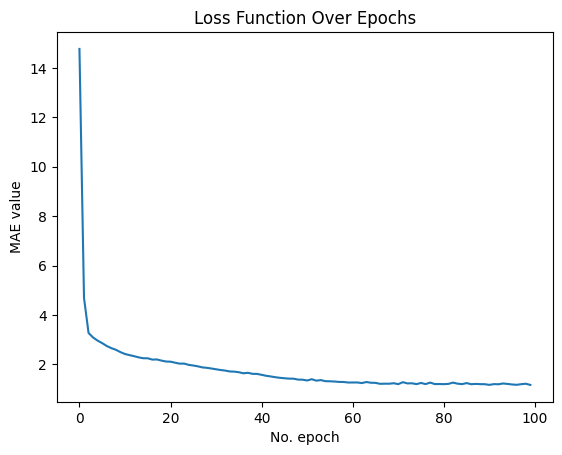

In [ ]:
import matplotlib.pyplot as plt

plt.plot(fit.history['mae'])
plt.title('Loss Function Over Epochs')
plt.ylabel('MAE value')
plt.xlabel('No. Epoch')
plt.show()

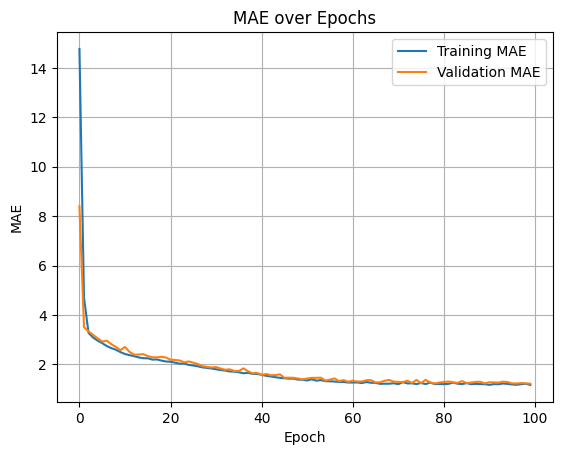

In [ ]:
plt.plot(fit.history['mae'], label='Training MAE')
plt.plot(fit.history['val_mae'], label='Validation MAE')
plt.title('MAE over Epochs')
plt.ylabel('MAE')
plt.xlabel('No. Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Tunning paramaters 

In [ ]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tensorflow.keras import models, layers
from sklearn.metrics import mean_absolute_error

best_mae = float('inf')
best_params = {}

for units1 in [128, 256]:
    for units2 in [32, 64]:
        for batch_size in [32, 64]:
            for epochs in [100, 250]:
                # Build model
                model = models.Sequential([
                    Input(shape=(X_train.shape[1],)),
                    layers.Dense(64, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)
                ])
                model.compile(optimizer='adam', loss='mse', metrics=['mae'])
                history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_split=0.2)

                # Evaluate on validation set or test set
                val_mae = history.history['val_mae'][-1]  # last epoch's val_mae
                if val_mae < best_mae:
                    best_mae = val_mae
                    best_params = {
                        'units1': units1,
                        'units2': units2,
                        'batch_size': batch_size,
                        'epochs': epochs
                    }

print("Best MAE:", best_mae)
print("Best Params:", best_params)

Best MAE: 1.1035234928131104
Best Params: {'units1': 128, 'units2': 32, 'batch_size': 32, 'epochs': 250}


## NEURAL NETWORK WITH SCALING THE OUTPUT 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
#Scaling parameters
numerical_variables_standardscaled = ["journey_duration","sh_days", "search_horizon_hours",
                       "journey_mileage"]

X_standardscaler = StandardScaler()
X[numerical_variables_standardscaled] = standardscaler.fit_transform(X[numerical_variables_standardscaled])

y_standardscaler = StandardScaler()
# y_train_scaled = y_train.values.reshape(-1, 1)
# y_test_scaled = y_test.values.reshape(-1,1)
y_train_scaled = y_standardscaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_standardscaler.fit_transform(y_test.reshape(-1, 1))

In [ ]:
model = models.Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

#Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

#Train the model
fit = model.fit(X_train, y_train_scaled, epochs=250, batch_size=32, validation_split=0.2)

#Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test_scaled)
print(f"Test MAE: {test_mae}")

Epoch 1/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8802 - mae: 0.7482 - val_loss: 0.6945 - val_mae: 0.5960
Epoch 2/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5895 - mae: 0.5682 - val_loss: 0.5496 - val_mae: 0.5386
Epoch 3/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5065 - mae: 0.5161 - val_loss: 0.5223 - val_mae: 0.5101
Epoch 4/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4956 - mae: 0.5060 - val_loss: 0.4864 - val_mae: 0.4839
Epoch 5/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4711 - mae: 0.4824 - val_loss: 0.4723 - val_mae: 0.4711
Epoch 6/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4309 - mae: 0.4560 - val_loss: 0.5178 - val_mae: 0.5055
Epoch 7/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4313 - mae: 0.4592 - val_loss: 0.4322 - val_mae: 0.4556
Epoch 8/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4181 - mae: 0.4580 - val_loss: 0.4232 - val_mae: 0.4376
Epoch 9/250
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

In [ ]:
y_pred_scaled = model.predict(X_test)

# Rescale the y_pred
y_pred_rescaled = y_standardscaler.inverse_transform(y_pred_scaled)

# Rescale the y_test
y_test_rescaled = y_standardscaler.inverse_transform(y_test_scaled)

# Otherwise, just use the original y_test (if not scaled)
from sklearn.metrics import mean_absolute_error
mae_original = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

print(f"Test MAE (in original price units): {mae_original}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test MAE (in original price units): 1.1610366915040096
